<a href="https://colab.research.google.com/github/sunday-praise/panda-matplotlib-exercises/blob/main/pandas_lesson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random

salary_list = [random.randint(50000,100000) for _ in range(1_000_000)]


In [2]:
import statistics

In [3]:
%%timeit
statistics.mean(salary_list)

952 ms ± 275 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [4]:
import numpy as np

In [5]:
%%timeit
np.median(salary_list)

154 ms ± 43.3 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [6]:
my_array = np.array([1, 2, 3, 4])

In [7]:
my_array.mean()

np.float64(2.5)

In [8]:
# Job titles
job_titles = np.array( ['Data Analyst', 'Data Scientist', 'Data Engineer', 'Machine Learning Engineer'])

# Base salaries
base_salaries = np.array([60000, 80000, 75000, 90000])

# Bonus rates
bonus_rates = np.array([.05, .1, .08, .12])

In [9]:
total_salaries = base_salaries * (1 + bonus_rates)

total_salaries

array([ 63000.,  88000.,  81000., 100800.])

In [10]:
!pip install itables

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 25.3 MB/s eta 0:00:00


In [11]:
!pip install datasets

In [12]:
from datasets import load_dataset
from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)

In [40]:
dataset = load_dataset('lukebarousse/data_jobs')

In [41]:
df = dataset['train'].to_pandas()

In [15]:
df

Loading ITables v2.7.3 from the internet... (need help?)


In [16]:
df[['job_title_short', 'job_location']].head()

Loading ITables v2.7.3 from the internet... (need help?)


In [17]:
df.job_title_short.unique()

array(['Senior Data Engineer', 'Data Analyst', 'Data Engineer',
       'Business Analyst', 'Data Scientist', 'Machine Learning Engineer',
       'Senior Data Analyst', 'Cloud Engineer', 'Senior Data Scientist',
       'Software Engineer'], dtype=object)

In [18]:
df [(df.job_title_short == 'Data Analyst') | (df.salary_year_avg > 100000)]

Loading ITables v2.7.3 from the internet... (need help?)


**Cleaning The Data**

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   job_title_short        785741 non-null  object 
 1   job_title              785740 non-null  object 
 2   job_location           784696 non-null  object 
 3   job_via                785733 non-null  object 
 4   job_schedule_type      773074 non-null  object 
 5   job_work_from_home     785741 non-null  bool   
 6   search_location        785741 non-null  object 
 7   job_posted_date        785741 non-null  object 
 8   job_no_degree_mention  785741 non-null  bool   
 9   job_health_insurance   785741 non-null  bool   
 10  job_country            785692 non-null  object 
 11  salary_rate            33067 non-null   object 
 12  salary_year_avg        22003 non-null   float64
 13  salary_hour_avg        10662 non-null   float64
 14  company_name           785723 non-nu

In [20]:
type(df.job_posted_date[0])

str

In [56]:
import pandas as pd
## converting this column to the appropriate format
df ['job_posted_date']= pd.to_datetime(df.job_posted_date)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

In [23]:
df.sort_values(by='job_posted_date', inplace=True)

In [24]:
df

Loading ITables v2.7.3 from the internet... (need help?)


In [25]:
## dropping a column that isn't needed
df.drop(labels='salary_hour_avg', axis=1, inplace=True)

In [26]:
df.dropna(subset=['salary_year_avg'], inplace=True)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22003 entries, 108883 to 327439
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        22003 non-null  object        
 1   job_title              22003 non-null  object        
 2   job_location           21723 non-null  object        
 3   job_via                22003 non-null  object        
 4   job_schedule_type      21987 non-null  object        
 5   job_work_from_home     22003 non-null  bool          
 6   search_location        22003 non-null  object        
 7   job_posted_date        22003 non-null  datetime64[ns]
 8   job_no_degree_mention  22003 non-null  bool          
 9   job_health_insurance   22003 non-null  bool          
 10  job_country            22003 non-null  object        
 11  salary_rate            22003 non-null  object        
 12  salary_year_avg        22003 non-null  float64       
 13  

**Analysing The Data**

In [28]:
df.describe()

Loading ITables v2.7.3 from the internet... (need help?)


In [29]:
min_salary = df.salary_year_avg.idxmin()

In [42]:
df.iloc[min_salary]

Loading ITables v2.7.3 from the internet... (need help?)


In [35]:
df.groupby('job_title_short')['salary_year_avg'].mean().reset_index()


Loading ITables v2.7.3 from the internet... (need help?)


In [43]:
df.groupby('job_title_short')[['salary_year_avg', 'salary_hour_avg']].median()

Loading ITables v2.7.3 from the internet... (need help?)


In [38]:
df.groupby(['job_title_short', 'job_country'])['salary_year_avg'].median()

Loading ITables v2.7.3 from the internet... (need help?)


In [44]:
df.groupby('job_title_short')[['salary_year_avg']].agg(['min', 'max', 'median'])

Loading ITables v2.7.3 from the internet... (need help?)


In [45]:
us_jobs = df [df ['job_country' ] == "United States"]

us_jobs = us_jobs [us_jobs ['salary_year_avg' ] . notna ( ) ]

In [46]:
us_jobs.groupby('job_title_short') ['salary_year_avg'].agg(['median', 'min', 'max', 'count']).sort_values(by='median')

Loading ITables v2.7.3 from the internet... (need help?)


In [32]:
import matplotlib.pyplot as plt
import numpy as np


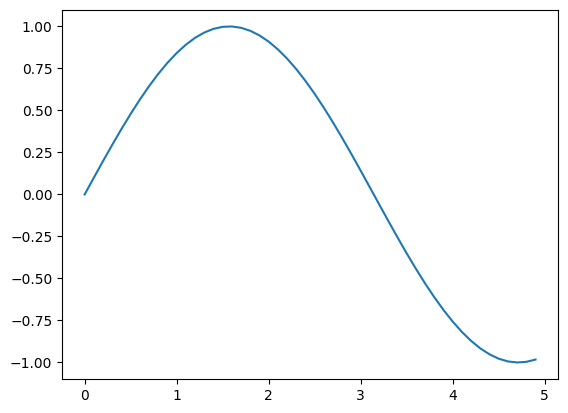

In [47]:
x = np.arange(0, 5, 0.1)
y = np.sin(x)
plt.plot(x, y)

##**Plotting Job Postings Dates**

In [48]:
df.job_posted_date.head()
df.job_posted_date.value_counts()

Loading ITables v2.7.3 from the internet... (need help?)


##**Monthly Counts**

In [57]:
df ['job_posted_month'] = df['job_posted_date'].dt.month

In [58]:
monthly_counts = df.job_posted_month.value_counts ()

monthly_counts = monthly_counts.sort_index()

monthly_counts

Loading ITables v2.7.3 from the internet... (need help?)


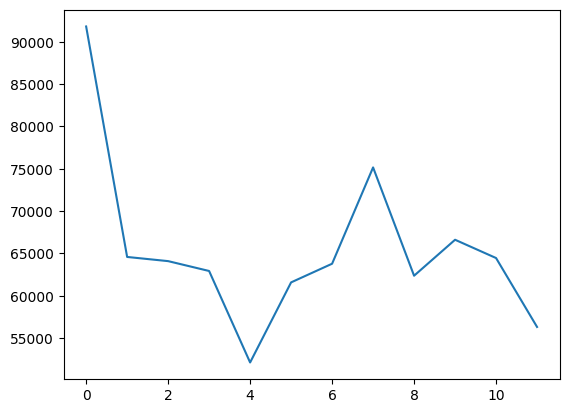

In [60]:
plt.plot(monthly_counts.values)

##**Series vs DataFrame**


*   One-Dimensioal
*   Indexed
*   Diverse Data Types






In [62]:
series = pd.Series([10,20,30,40,50], index=['a','b','c','d','e'])

##Bar Chart - Counts of Job Postings

In [68]:
job_counts = df.job_title_short.value_counts()#.head(3)

<BarContainer object of 10 artists>

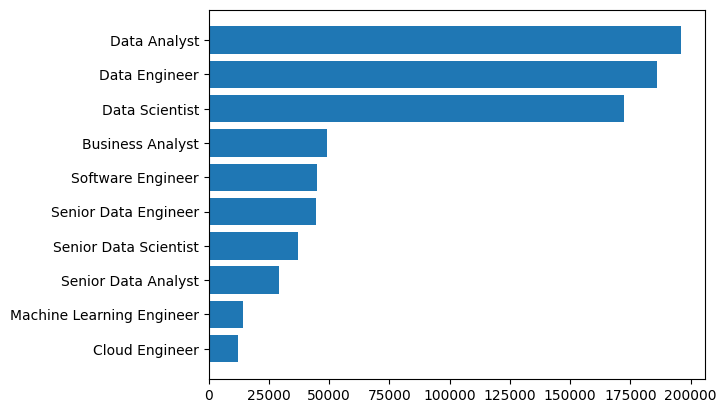

In [71]:
job_counts = job_counts.sort_values(ascending=True)
plt.barh(job_counts.index, job_counts)

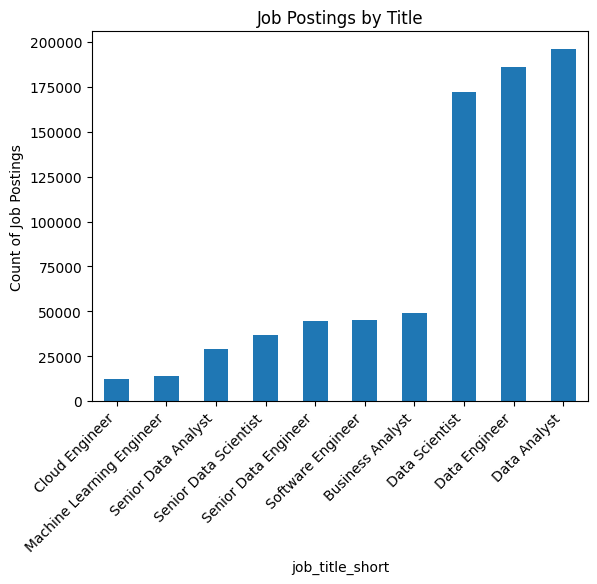

In [75]:
job_counts.plot(kind='bar')
#plt.bar(job_counts.index, job_counts)
plt.title('Job Postings by Title')
#plt.xlabel('Number of Postings')
plt.ylabel('Count of Job Postings')
plt.xticks(rotation=45, ha='right')
plt.show()

##**Job Salary Trend**

In [76]:
df [ ['job_posted_date', 'salary_year_avg' ]].dropna(subset=['salary_year_avg'])

Loading ITables v2.7.3 from the internet... (need help?)


<Axes: xlabel='job_posted_date', ylabel='salary_year_avg'>

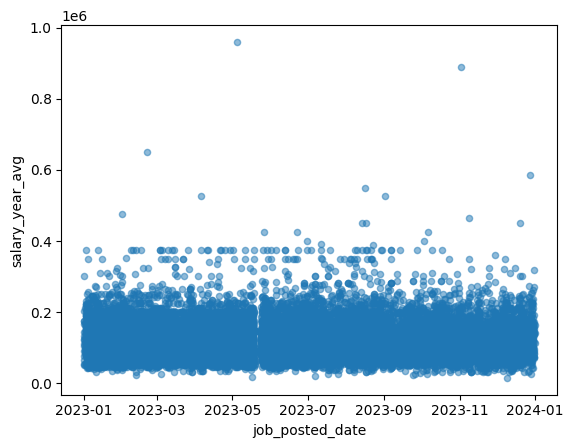

In [81]:
df.plot(x='job_posted_date', y='salary_year_avg', kind='scatter', alpha=0.5)

/tmp/ipykernel_5962/1088774587.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample('M', on='job_posted_date')['salary_year_avg'].median().plot()


<Axes: xlabel='job_posted_date'>

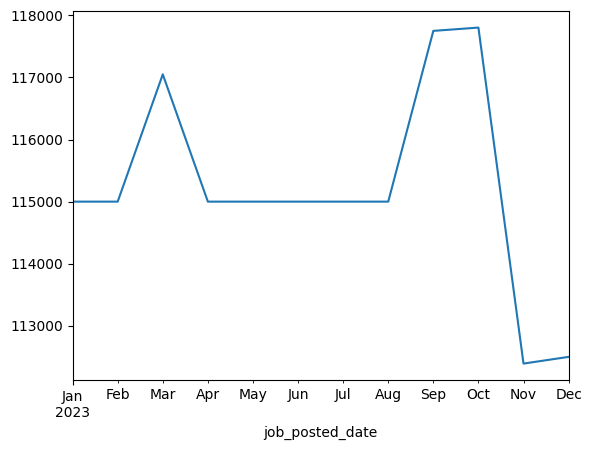

In [82]:
df.resample('M', on='job_posted_date')['salary_year_avg'].median().plot()

##Calculating the Median Salary  Based on the Job Title

####Median Salary vs Data Science Jobs



In [2]:
# Installing datasets Library
!pip install datasets

# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset ['train' ] .to_pandas ()

# Data Cleanup
df ['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data_jobs.csv:   0%|          | 0.00/231M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

In [85]:
df.groupby('job_title_short')['salary_year_avg'].median().sort_values()

Loading ITables v2.7.3 from the internet... (need help?)


In [86]:
df.groupby('job_title_short')['salary_year_avg'].mean().sort_values()

Loading ITables v2.7.3 from the internet... (need help?)


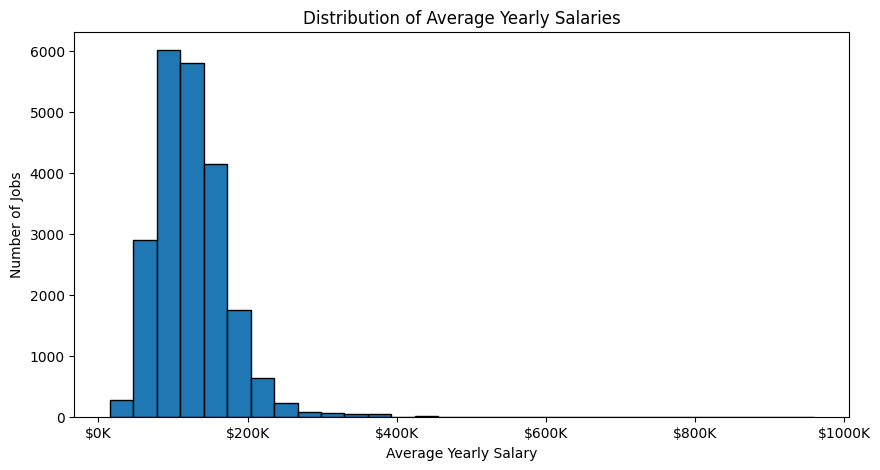

In [88]:
from matplotlib. ticker import FuncFormatter

# Drop rows with NA values in 'salary_year_avg'
df_nan = df.dropna(subset=['salary_year_avg'])

# Define the formatter function
def to_k(x, pos):
  """Convert number to string with 'K' as thousands."""
  return f'${int(x/1000)}K'

# Create formatter using FuncFormatter
formatter = FuncFormatter(to_k)

# Create histogram
plt.figure(figsize=(10, 5))
plt.hist(df_nan['salary_year_avg'], bins=30, edgecolor='black')

# Set title and labels
plt.title('Distribution of Average Yearly Salaries')
plt.xlabel('Average Yearly Salary')
plt.ylabel('Number of Jobs')

# Apply the formatter to the x-axis
plt.gca().xaxis.set_major_formatter(formatter)

# Show the plot
plt. show()

In [3]:
job_salary = df.groupby ('job_title_short')['salary_year_avg'].median().sort_values()

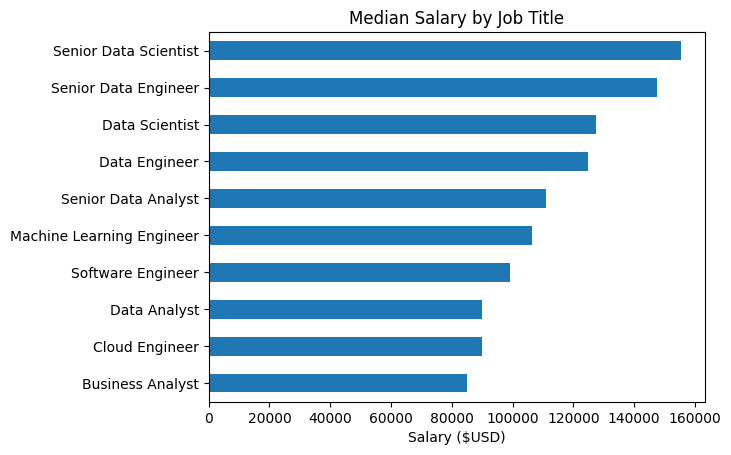

In [4]:
job_salary.plot(kind='barh')
plt.xlabel('Salary ($USD)')
plt.ylabel('')
plt.title('Median Salary by Job Title')
plt.show()